In [1]:
# ============================================================
# LamC Parameter Classification — CLEAN VERSION
# Fixes: Logits_Threshold excluded, bootstrap CI,
#        permutation test, consistent CM, mean±std
# n=129 (67 Control, 62 LamCG489V)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
import os

os.makedirs("./results_lamc_param", exist_ok=True)

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv('control_mutant_full.csv')

# Labels
df['Target'] = df['Name'].apply(
    lambda x: 0 if 'Control' in x else 1 if 'LamCG489V' in x else np.nan)
df['Gender'] = df['Name'].apply(
    lambda x: 0 if '3wf' in x else 1 if '3wm' in x else np.nan)
df.dropna(subset=['Target','Gender'], inplace=True)
df.reset_index(drop=True, inplace=True)
df = df.rename(columns={'Mean DD:': 'Mean_DD'})

# CRITICAL: exclude Logits_Threshold (previous model output = leakage)
# and Calculation ROI (non-physiological)
print(f"n={len(df)}")
print(f"Control: {(df['Target']==0).sum()}  LamCG489V: {(df['Target']==1).sum()}")
print(f"Female: {(df['Gender']==0).sum()}  Male: {(df['Gender']==1).sum()}")

# ── Feature engineering ───────────────────────────────────────
df['DD_SD_Diff']  = df['Mean_DD'] - df['Mean SD']
df['HP_AI_Ratio'] = df['Mean HP'] / df['Mean AI'].replace(0, np.nan)
df.fillna(0, inplace=True)

# Final feature set (same as original manuscript)
# Gender included as biological covariate
features = ['DD_SD_Diff', 'Mean_DD', 'Mean FS', 'STD HR',
            'HP_AI_Ratio', 'Gender']
X = df[features]
y = df['Target'].astype(int)

print(f"\nFeatures: {features}")
print(f"X shape: {X.shape}")

n=129
Control: 67  LamCG489V: 62
Female: 64  Male: 65

Features: ['DD_SD_Diff', 'Mean_DD', 'Mean FS', 'STD HR', 'HP_AI_Ratio', 'Gender']
X shape: (129, 6)


In [2]:
# ── Bootstrap CI helper ───────────────────────────────────────
def bootstrap_ci(y_true, y_proba, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    accs, aucs = [], []
    for _ in range(n_boot):
        idx  = rng.integers(0, n, size=n)
        yt_b = y_true[idx]
        yp_b = y_proba[idx]
        if len(np.unique(yt_b)) < 2:
            continue
        accs.append(accuracy_score(yt_b, (yp_b>=0.5).astype(int)))
        fpr_b, tpr_b, _ = roc_curve(yt_b, yp_b)
        aucs.append(auc(fpr_b, tpr_b))
    return ((np.percentile(accs,2.5), np.percentile(accs,97.5)),
            (np.percentile(aucs,2.5), np.percentile(aucs,97.5)))

print("Bootstrap CI helper defined")

Bootstrap CI helper defined


In [3]:
# ── Supervised: RF with StratifiedKFold ───────────────────────
rf = RandomForestClassifier(
    max_depth=6, max_features='sqrt',
    min_samples_leaf=2, min_samples_split=6,
    n_estimators=500, bootstrap=True, random_state=42)

skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stats = []
all_pred_rows = []
conf_matrices = []
tprs, mean_fpr = [], np.linspace(0,1,100)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipe = make_pipeline(StandardScaler(), rf.__class__(**rf.get_params()))
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    acc     = accuracy_score(y_test, y_pred)
    auc_val = roc_auc_score(y_test, y_proba)
    cm      = confusion_matrix(y_test, y_pred).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    tprs.append(np.interp(mean_fpr, fpr, tpr))

    print(f"  Fold {fold}: Acc={acc:.4f}  AUROC={auc_val:.4f}")

    stats.append({'Fold':fold, 'Num Training':len(train_idx),
                  'Num Testing':len(test_idx),
                  'Accuracy':acc, 'AUROC':auc_val})
    conf_matrices.append(cm_norm)

    names_arr = df['Name'].values
    for i in range(len(test_idx)):
        all_pred_rows.append({
            'SampleID': names_arr[test_idx[i]],
            'Fold': fold,
            'Raw_Pred': float(y_proba[i]),
            'Label': int(y_test.iloc[i])
        })

df_stats   = pd.DataFrame(stats)
mean_acc   = df_stats['Accuracy'].mean()
std_acc    = df_stats['Accuracy'].std()
mean_auc   = df_stats['AUROC'].mean()
std_auc    = df_stats['AUROC'].std()
avg_cm     = np.mean(conf_matrices, axis=0)
mean_tpr   = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0

df_preds   = pd.DataFrame(all_pred_rows)
all_y      = df_preds['Label'].values
all_p      = df_preds['Raw_Pred'].values
ci_acc, ci_auc = bootstrap_ci(all_y, all_p)
overall_auc = roc_auc_score(all_y, all_p)
overall_acc = accuracy_score(all_y, (all_p>=0.5).astype(int))

print(f"\nSUPERVISED LamC RF (n=129)")
print(f"  Mean±Std Acc  = {mean_acc:.4f} ± {std_acc:.4f}")
print(f"  Mean±Std AUROC= {mean_auc:.4f} ± {std_auc:.4f}")
print(f"  Overall Acc   = {overall_acc:.4f}  95%CI [{ci_acc[0]:.4f},{ci_acc[1]:.4f}]")
print(f"  Overall AUROC = {overall_auc:.4f}  95%CI [{ci_auc[0]:.4f},{ci_auc[1]:.4f}]")

# Add mean/std rows
mean_row = {c: df_stats[c].mean() if c!='Fold' else 'Mean' for c in df_stats.columns}
std_row  = {c: df_stats[c].std()  if c!='Fold' else 'Std'  for c in df_stats.columns}
df_out   = pd.concat([df_stats,
                       pd.DataFrame([mean_row]),
                       pd.DataFrame([std_row])], ignore_index=True)
df_out.to_csv('./results_lamc_param/kfold_stats_lamc.csv', index=False)
df_preds.to_csv('./results_lamc_param/kfold_preds_lamc.csv', index=False)
print(" Saved: ./results_lamc_param/")

  Fold 1: Acc=0.7692  AUROC=0.8214
  Fold 2: Acc=0.9231  AUROC=0.9107
  Fold 3: Acc=0.8077  AUROC=0.8284
  Fold 4: Acc=0.7308  AUROC=0.7633
  Fold 5: Acc=0.6800  AUROC=0.6987

SUPERVISED LamC RF (n=129)
  Mean±Std Acc  = 0.7822 ± 0.0919
  Mean±Std AUROC= 0.8045 ± 0.0791
  Overall Acc   = 0.7829  95%CI [0.7132,0.8527]
  Overall AUROC = 0.8113  95%CI [0.7243,0.8851]
 Saved: ./results_lamc_param/


In [4]:
# ── Permutation test ──────────────────────────────────────────
print("Running permutation test (100 permutations)...")
rf_perm  = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_perm = make_pipeline(StandardScaler(), rf_perm)
skf_perm  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score_obs, perm_scores, p_value = permutation_test_score(
    pipe_perm, X, y,
    scoring='roc_auc',
    cv=skf_perm,
    n_permutations=100,
    random_state=42,
    n_jobs=-1
)
print(f"  Observed AUROC = {score_obs:.4f}")
print(f"  Permuted mean  = {perm_scores.mean():.4f} ± {perm_scores.std():.4f}")
print(f"  p-value        = {p_value:.4f}")
sig = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
print(f"  Result is {sig}")

import pandas as pd
pd.DataFrame({'observed':[score_obs],
              'perm_mean':[perm_scores.mean()],
              'p_value':[p_value]}).to_csv(
    './results_lamc_param/permutation_lamc.csv', index=False)

Running permutation test (100 permutations)...
  Observed AUROC = 0.7940
  Permuted mean  = 0.4938 ± 0.0697
  p-value        = 0.0099
  Result is SIGNIFICANT


In [5]:
# ── Unsupervised: KMeans stability (10 runs) ─────────────────
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
y_arr    = y.values
accs_km  = []
best_labels, best_acc = None, 0

for seed in range(10):
    km     = KMeans(n_clusters=2, init='k-means++',
                    n_init=10, random_state=seed)
    labels = km.fit_predict(X_scaled)
    contingency = pd.crosstab(y_arr, labels)
    row_ind, col_ind = linear_sum_assignment(-contingency.values)
    label_map   = dict(zip(col_ind, row_ind))
    mapped      = np.array([label_map[l] for l in labels])
    acc_km      = accuracy_score(y_arr, mapped)
    accs_km.append(acc_km)
    if acc_km > best_acc:
        best_acc    = acc_km
        best_labels = mapped.copy()

print(f"\nUNSUPERVISED KMeans (10 runs)")
print(f"  Accuracy = {np.mean(accs_km):.4f} ± {np.std(accs_km):.4f}")
print(f"  Best run = {best_acc:.4f}")


UNSUPERVISED KMeans (10 runs)
  Accuracy = 0.6450 ± 0.0186
  Best run = 0.6822


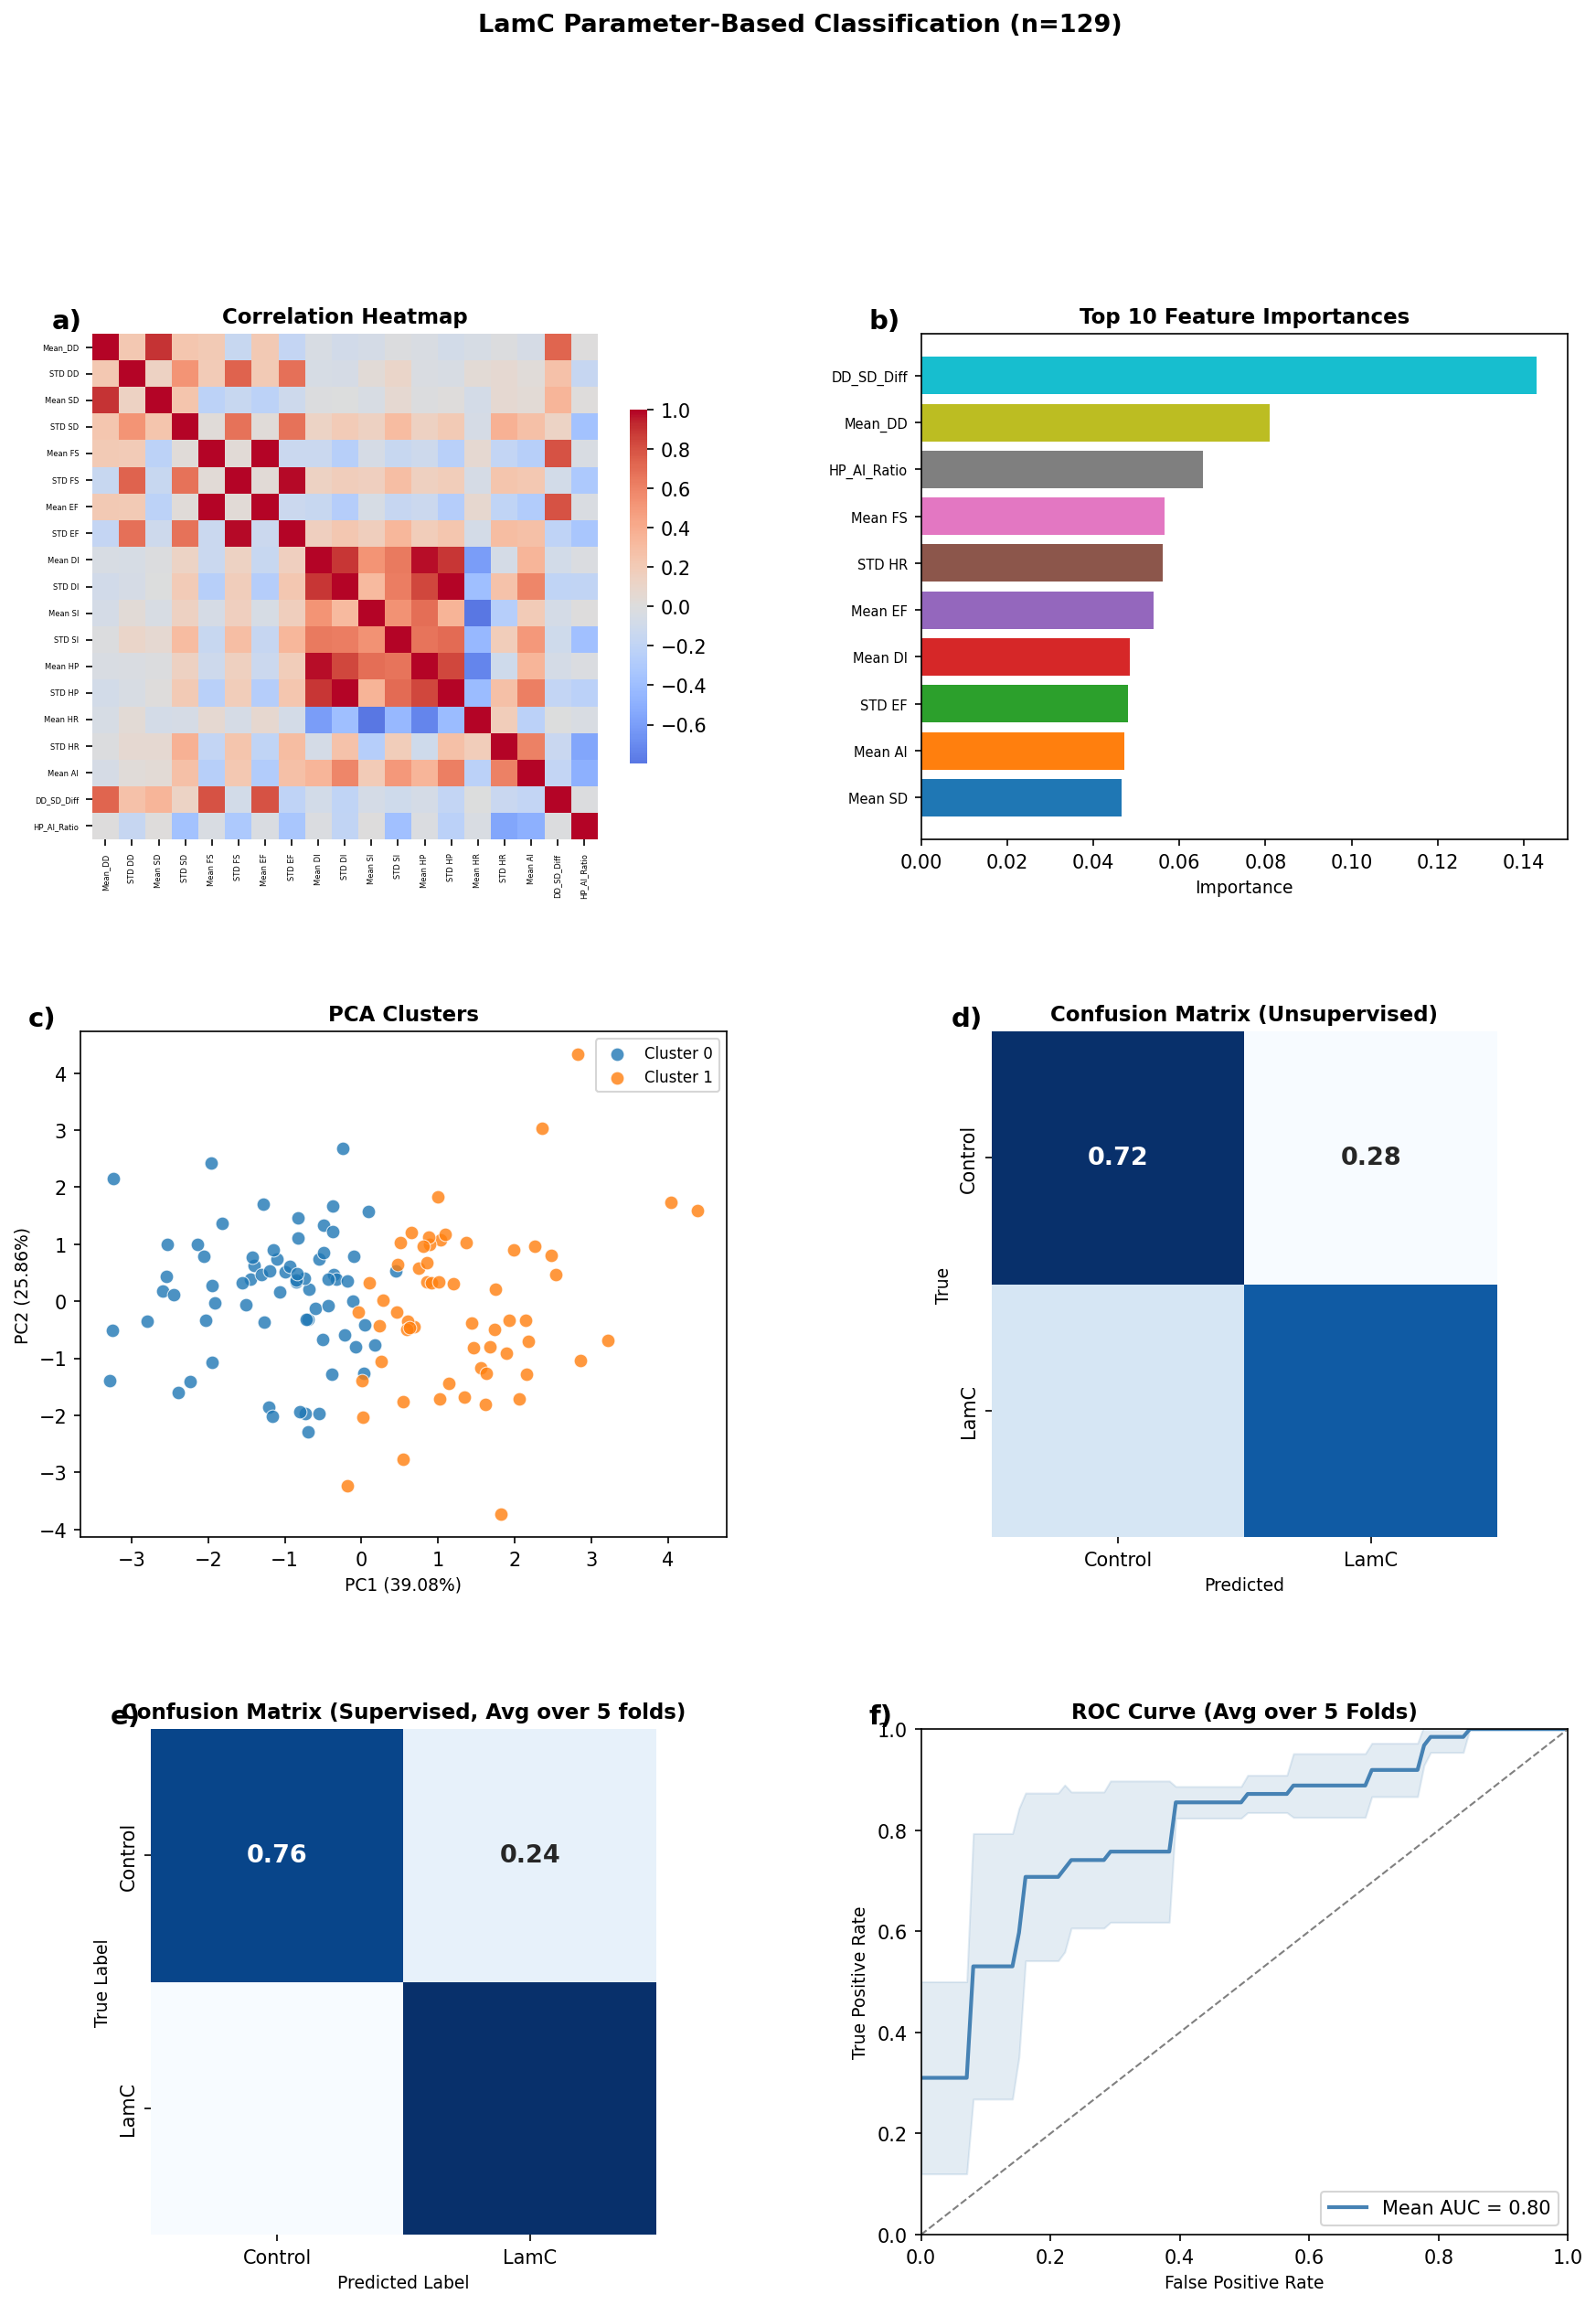

Figure saved: ./results_lamc_param/lamc_param_figure.tiff


In [8]:
# ── Combined Figure — 3×2 grid ────────────────────────────────
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Compute correlation matrix
exclude_cols = ['Unnamed: 0','Name','Calculation ROI',
                'Logits_Threshold','Target','Gender']
all_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]
corr_matrix  = df[all_num_cols].corr()

# RF importance on all features
rf_all = RandomForestClassifier(n_estimators=500, random_state=42)
rf_all.fit(df[all_num_cols], y)
imp_series = pd.Series(rf_all.feature_importances_,
                        index=all_num_cols).sort_values(ascending=False).head(10)

# PCA for cluster plot
X_scaled        = StandardScaler().fit_transform(X)
pca             = PCA(n_components=2, random_state=42)
pca_2d          = pca.fit_transform(X_scaled)
explained       = pca.explained_variance_ratio_
best_labels_arr = np.array(best_labels)

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 18), dpi=150)
plt.subplots_adjust(hspace=0.38, wspace=0.30)

ax_corr     = axes[0, 0]
ax_feat     = axes[0, 1]
ax_pca      = axes[1, 0]
ax_cm_unsup = axes[1, 1]
ax_cm_sup   = axes[2, 0]
ax_roc      = axes[2, 1]

# ── a) Correlation Heatmap ─────────────────────────────────
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7},
            xticklabels=True, yticklabels=True,
            ax=ax_corr, annot=False)
ax_corr.set_title('Correlation Heatmap', fontsize=11, fontweight='bold')
ax_corr.tick_params(axis='both', labelsize=4)

# ── b) Top 10 Feature Importances ─────────────────────────
colors_imp = plt.cm.tab10(np.linspace(0, 1, 10))
ax_feat.barh(imp_series.index[::-1], imp_series.values[::-1],
             color=colors_imp)
ax_feat.set_xlabel('Importance', fontsize=9)
ax_feat.set_title('Top 10 Feature Importances',
                   fontsize=11, fontweight='bold')
ax_feat.tick_params(axis='y', labelsize=7)

# ── c) PCA Clusters ────────────────────────────────────────
color_map = {0: '#1f77b4', 1: '#ff7f0e'}
for lab in [0, 1]:
    mask = best_labels_arr == lab
    ax_pca.scatter(pca_2d[mask, 0], pca_2d[mask, 1],
                   c=color_map[lab],
                   label=f'Cluster {lab}',
                   alpha=0.8, edgecolors='w',
                   s=50, linewidths=0.5)
ax_pca.set_xlabel(f'PC1 ({explained[0]*100:.2f}%)', fontsize=9)
ax_pca.set_ylabel(f'PC2 ({explained[1]*100:.2f}%)', fontsize=9)
ax_pca.set_title('PCA Clusters', fontsize=11, fontweight='bold')
ax_pca.legend(fontsize=8)

# ── d) Confusion Matrix Unsupervised ──────────────────────
cm_unsup      = confusion_matrix(y.values, best_labels_arr).astype(float)
cm_unsup_norm = cm_unsup / cm_unsup.sum(axis=1, keepdims=True)
sns.heatmap(cm_unsup_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Control', 'LamC'],
            yticklabels=['Control', 'LamC'],
            ax=ax_cm_unsup, cbar=False, square=True,
            annot_kws={'size': 13, 'weight': 'bold'})
ax_cm_unsup.set_xlabel('Predicted', fontsize=9)
ax_cm_unsup.set_ylabel('True', fontsize=9)
ax_cm_unsup.set_title('Confusion Matrix (Unsupervised)',
                        fontsize=11, fontweight='bold')

# ── e) Confusion Matrix Supervised ────────────────────────
sns.heatmap(avg_cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Control', 'LamC'],
            yticklabels=['Control', 'LamC'],
            ax=ax_cm_sup, cbar=False, square=True,
            annot_kws={'size': 13, 'weight': 'bold'})
ax_cm_sup.set_xlabel('Predicted Label', fontsize=9)
ax_cm_sup.set_ylabel('True Label', fontsize=9)
ax_cm_sup.set_title('Confusion Matrix (Supervised, Avg over 5 folds)',
                     fontsize=11, fontweight='bold')

# ── f) ROC Curve ───────────────────────────────────────────
mean_tpr_arr      = np.mean(tprs, axis=0)
mean_tpr_arr[-1]  = 1.0
std_tpr           = np.std(tprs, axis=0)

ax_roc.plot(mean_fpr, mean_tpr_arr,
            color='steelblue', lw=2,
            label=f'Mean AUC = {mean_auc:.2f}')
ax_roc.fill_between(mean_fpr,
                     mean_tpr_arr - std_tpr,
                     mean_tpr_arr + std_tpr,
                     alpha=0.15, color='steelblue')
ax_roc.plot([0,1],[0,1],'--', color='gray', lw=1)
ax_roc.set_xlabel('False Positive Rate', fontsize=9)
ax_roc.set_ylabel('True Positive Rate', fontsize=9)
ax_roc.set_title('ROC Curve (Avg over 5 Folds)',
                  fontsize=11, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)

# ── Panel labels ───────────────────────────────────────────
for ax, letter in zip([ax_corr, ax_feat, ax_pca,
                        ax_cm_unsup, ax_cm_sup, ax_roc],
                       ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']):
    ax.text(-0.08, 1.05, letter,
            transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')

plt.suptitle('LamC Parameter-Based Classification (n=129)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('./results_lamc_param/lamc_param_figure.tiff',
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: ./results_lamc_param/lamc_param_figure.tiff")

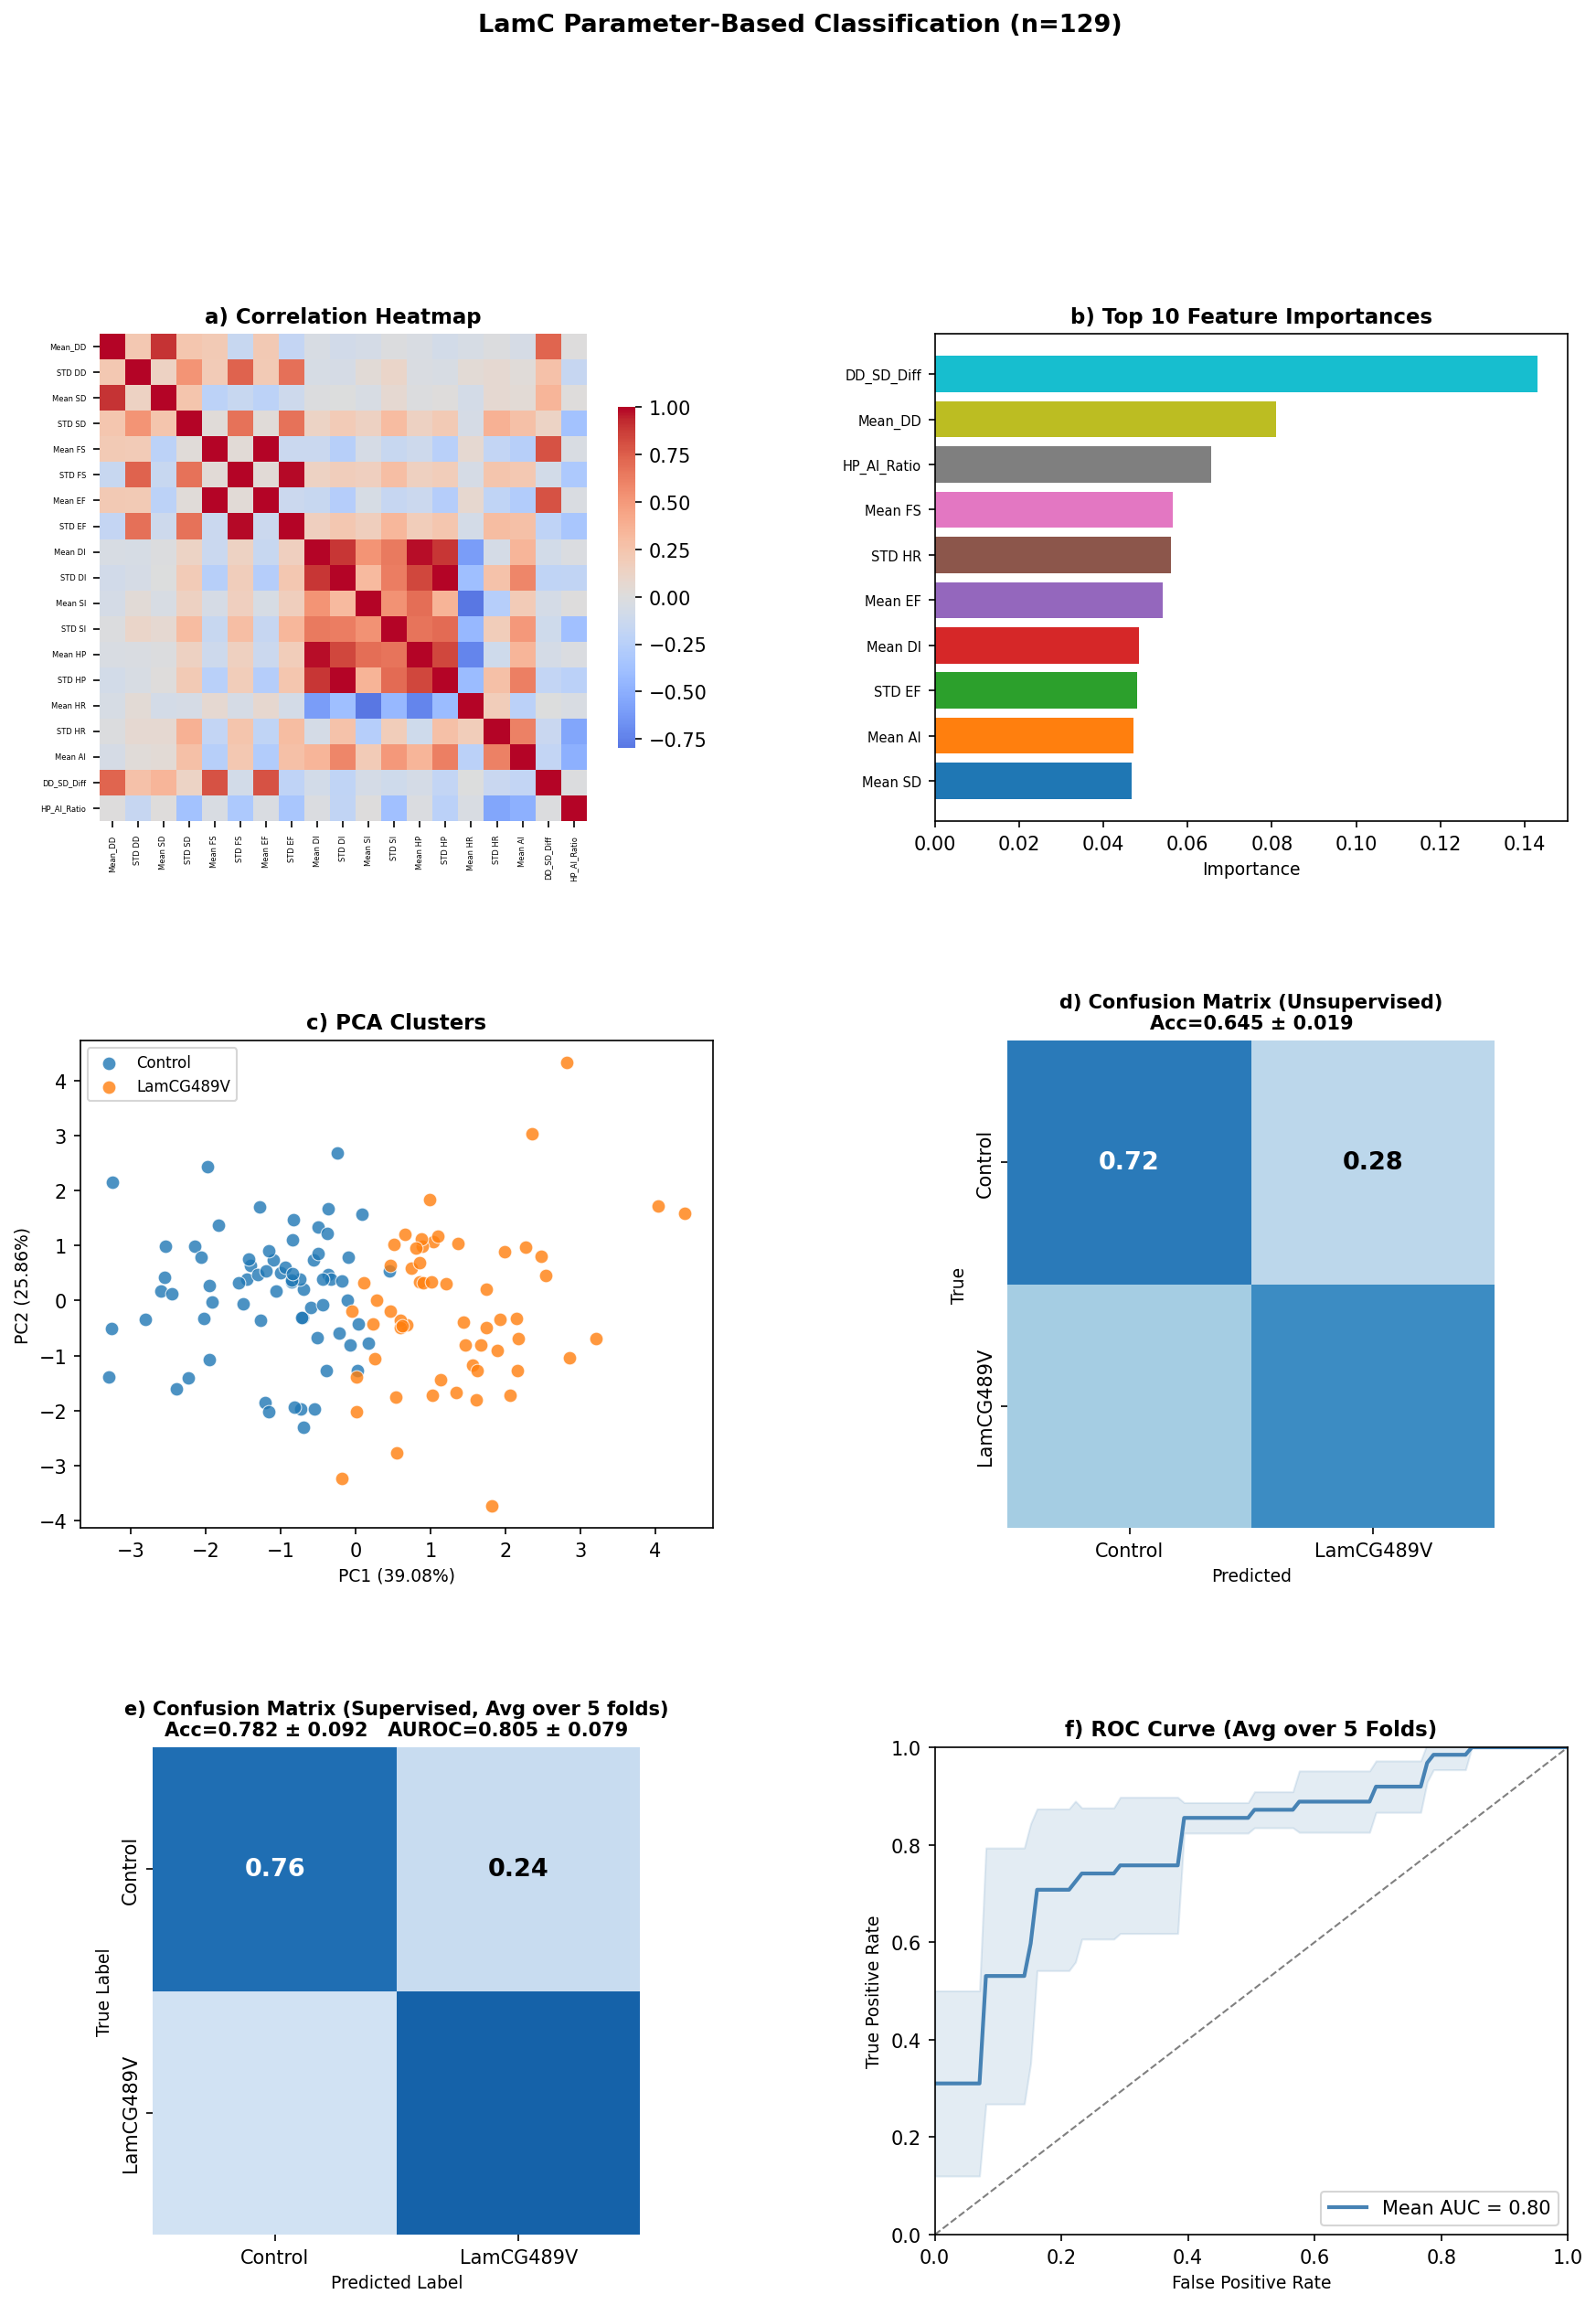

Figure saved: ./results_lamc_param/lamc_param_figure.tiff


In [10]:
# ── Combined Figure — 3×2 grid ────────────────────────────────
from matplotlib.patches import Patch

# Compute correlation matrix
exclude_cols = ['Unnamed: 0','Name','Calculation ROI',
                'Logits_Threshold','Target','Gender']
all_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]
corr_matrix  = df[all_num_cols].corr()

# RF importance on all features
rf_all = RandomForestClassifier(n_estimators=500, random_state=42)
rf_all.fit(df[all_num_cols], y)
imp_series = pd.Series(rf_all.feature_importances_,
                        index=all_num_cols).sort_values(ascending=False).head(10)

# PCA for cluster plot
X_scaled        = StandardScaler().fit_transform(X)
pca             = PCA(n_components=2, random_state=42)
pca_2d          = pca.fit_transform(X_scaled)
explained       = pca.explained_variance_ratio_
best_labels_arr = np.array(best_labels)

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 18), dpi=150)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

ax_corr     = axes[0, 0]
ax_feat     = axes[0, 1]
ax_pca      = axes[1, 0]
ax_cm_unsup = axes[1, 1]
ax_cm_sup   = axes[2, 0]
ax_roc      = axes[2, 1]

# ── a) Correlation Heatmap ─────────────────────────────────
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7},
            xticklabels=True, yticklabels=True,
            ax=ax_corr, annot=False)
ax_corr.set_title('a) Correlation Heatmap',
                   fontsize=11, fontweight='bold')
ax_corr.tick_params(axis='both', labelsize=4)

# ── b) Top 10 Feature Importances ─────────────────────────
colors_imp = plt.cm.tab10(np.linspace(0, 1, 10))
ax_feat.barh(imp_series.index[::-1], imp_series.values[::-1],
             color=colors_imp)
ax_feat.set_xlabel('Importance', fontsize=9)
ax_feat.set_title('b) Top 10 Feature Importances',
                   fontsize=11, fontweight='bold')
ax_feat.tick_params(axis='y', labelsize=7)

# ── c) PCA Clusters ────────────────────────────────────────
color_map   = {0: '#1f77b4', 1: '#ff7f0e'}
class_names = {0: 'Control', 1: 'LamCG489V'}
for lab in [0, 1]:
    mask = best_labels_arr == lab
    ax_pca.scatter(pca_2d[mask, 0], pca_2d[mask, 1],
                   c=color_map[lab],
                   label=class_names[lab],
                   alpha=0.8, edgecolors='w',
                   s=50, linewidths=0.5)
ax_pca.set_xlabel(f'PC1 ({explained[0]*100:.2f}%)', fontsize=9)
ax_pca.set_ylabel(f'PC2 ({explained[1]*100:.2f}%)', fontsize=9)
ax_pca.set_title('c) PCA Clusters', fontsize=11, fontweight='bold')
ax_pca.legend(fontsize=8)

# ── d) Confusion Matrix Unsupervised ──────────────────────
cm_unsup      = confusion_matrix(y.values, best_labels_arr).astype(float)
cm_unsup_norm = cm_unsup / cm_unsup.sum(axis=1, keepdims=True)
sns.heatmap(cm_unsup_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Control', 'LamCG489V'],
            yticklabels=['Control', 'LamCG489V'],
            ax=ax_cm_unsup, cbar=False, square=True,
            vmin=0, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
for text in ax_cm_unsup.texts:
    val = float(text.get_text())
    text.set_color('white' if val > 0.5 else 'black')
ax_cm_unsup.set_xlabel('Predicted', fontsize=9)
ax_cm_unsup.set_ylabel('True', fontsize=9)
ax_cm_unsup.set_title(
    f'd) Confusion Matrix (Unsupervised)\nAcc={np.mean(accs_km):.3f} ± {np.std(accs_km):.3f}',
    fontsize=10, fontweight='bold')

# ── e) Confusion Matrix Supervised ────────────────────────
sns.heatmap(avg_cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Control', 'LamCG489V'],
            yticklabels=['Control', 'LamCG489V'],
            ax=ax_cm_sup, cbar=False, square=True,
            vmin=0, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
for text in ax_cm_sup.texts:
    val = float(text.get_text())
    text.set_color('white' if val > 0.5 else 'black')
ax_cm_sup.set_xlabel('Predicted Label', fontsize=9)
ax_cm_sup.set_ylabel('True Label', fontsize=9)
ax_cm_sup.set_title(
    f'e) Confusion Matrix (Supervised, Avg over 5 folds)\n'
    f'Acc={mean_acc:.3f} ± {std_acc:.3f}   AUROC={mean_auc:.3f} ± {std_auc:.3f}',
    fontsize=10, fontweight='bold')

# ── f) ROC Curve ───────────────────────────────────────────
mean_tpr_arr     = np.mean(tprs, axis=0)
mean_tpr_arr[-1] = 1.0
std_tpr          = np.std(tprs, axis=0)

ax_roc.plot(mean_fpr, mean_tpr_arr,
            color='steelblue', lw=2,
            label=f'Mean AUC = {mean_auc:.2f}')
ax_roc.fill_between(mean_fpr,
                     mean_tpr_arr - std_tpr,
                     mean_tpr_arr + std_tpr,
                     alpha=0.15, color='steelblue')
ax_roc.plot([0,1],[0,1],'--', color='gray', lw=1)
ax_roc.set_xlabel('False Positive Rate', fontsize=9)
ax_roc.set_ylabel('True Positive Rate', fontsize=9)
ax_roc.set_title('f) ROC Curve (Avg over 5 Folds)',
                  fontsize=11, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)

plt.suptitle('LamC Parameter-Based Classification (n=129)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('./results_lamc_param/lamc_param_figure.tiff',
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: ./results_lamc_param/lamc_param_figure.tiff")